<a href="https://colab.research.google.com/github/vinayak932/Phishing_detection_model/blob/main/Phishing_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipaddress

In [3]:
dataset = pd.read_csv('url_features_extracted1.csv')

In [4]:
dataset.head()

,URL,url_length,has_ip_address,dot_count,https_flag,url_entropy,token_count,subdomain_count,query_param_count,tld_length,path_length,has_hyphen_in_domain,number_of_digits,tld_popularity,suspicious_file_extension,domain_name_length,percentage_numeric_chars,ClassLabel
0,https://keraekken-loagginnusa.godaddysites.com/,47,0,2,1,4.250669,6,1,1,3,1,1,0,1,0,12,0.0,0.0
1,https://metamsk01lgiix.godaddysites.com/,40,0,2,1,4.196439,6,1,1,3,1,0,2,1,0,12,5.0,0.0
2,http://myglobaltech.in/,23,0,1,0,3.936180,5,0,1,2,1,0,0,0,0,12,0.0,0.0
3,http://djtool-for-spotify.com/,30,0,1,0,3.894740,5,0,1,3,1,1,0,1,0,18,0.0,0.0
4,https://scearmcoommunnlty.com/invent/freind/get,47,0,1,1,4.143127,7,0,1,3,18,0,0,1,0,17,0.0,0.0


In [5]:
dataset.isna().value_counts()

URL    url_length  has_ip_address  dot_count  https_flag  url_entropy  token_count  subdomain_count  query_param_count  tld_length  path_length  has_hyphen_in_domain  number_of_digits  tld_popularity  suspicious_file_extension  domain_name_length  percentage_numeric_chars  ClassLabel
False  False       False           False      False       False        False        False            False              False       False        False                 False             False           False                      False               False                     False         101218
                                                                                                                                                                                                                                                                                  True               1
Name: count, dtype: int64

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101219 entries, 0 to 101218
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   URL                        101219 non-null  object 
 1   url_length                 101219 non-null  int64  
 2   has_ip_address             101219 non-null  int64  
 3   dot_count                  101219 non-null  int64  
 4   https_flag                 101219 non-null  int64  
 5   url_entropy                101219 non-null  float64
 6   token_count                101219 non-null  int64  
 7   subdomain_count            101219 non-null  int64  
 8   query_param_count          101219 non-null  int64  
 9   tld_length                 101219 non-null  int64  
 10  path_length                101219 non-null  int64  
 11  has_hyphen_in_domain       101219 non-null  int64  
 12  number_of_digits           101219 non-null  int64  
 13  tld_popularity             10

In [7]:
dataset[dataset['ClassLabel'].isna()]

,URL,url_length,has_ip_address,dot_count,https_flag,url_entropy,token_count,subdomain_count,query_param_count,tld_length,path_length,has_hyphen_in_domain,number_of_digits,tld_popularity,suspicious_file_extension,domain_name_length,percentage_numeric_chars,ClassLabel
65118,https://www.chocolatleroux.com,30,0,2,1,3.898069,5,1,1,3,0,0,0,1,0,14,0.0,NaN


In [8]:
dataset = dataset.dropna(subset=['ClassLabel'])

In [9]:
dataset.isna().sum()

,0
URL,0
url_length,0
has_ip_address,0
dot_count,0
https_flag,0
url_entropy,0
token_count,0
subdomain_count,0
query_param_count,0
tld_length,0


In [10]:
dataset['ClassLabel'].value_counts()

,count
ClassLabel,
0.0,63678
1.0,37540


In [11]:
dataset['URL'].duplicated().sum()

np.int64(346)

In [12]:
dataset['ClassLabel'].value_counts(normalize = True) *100

,proportion
ClassLabel,
0.0,62.911735
1.0,37.088265


In [13]:
dataset[dataset['ClassLabel'] == 0]['URL'].head(10)

,URL
0,https://keraekken-loagginnusa.godaddysites.com/
1,https://metamsk01lgiix.godaddysites.com/
2,http://myglobaltech.in/
3,http://djtool-for-spotify.com/
4,https://scearmcoommunnlty.com/invent/freind/get
5,http://instagramtick-git-master-behhruzs-proje...
6,http://bafybeicsc2iofzskpmb56uzh72jirndpnmcs42...
7,http://login-page-105531.square.site/
8,http://bt-101274.weeblysite.com/
9,http://molina-c2f.pages.dev/


In [14]:
dataset[dataset['ClassLabel'] == 1]['URL'].head(10)

,URL
63678,https://stackoverflow.com/questions/tagged/php
63679,https://stackoverflow.com/questions/tagged/mic...
63680,https://stackoverflow.com/questions/tagged/sql
63681,https://stackoverflow.com/questions/79030270/h...
63682,https://stackoverflow.com/questions/tagged/java
63683,https://stackoverflow.com/questions/tagged/iwyu
63684,https://stackoverflow.com/questions/tagged/and...
63685,https://stackoverflow.com/questions/tagged/dep...
63686,https://stackoverflow.com/questions/tagged/mac...
63687,https://stackoverflow.com/questions/tagged/build


In [15]:
dataset['URL'].nunique()

100872

In [16]:
dataset.groupby('URL')['ClassLabel'].nunique().value_counts()

,count
ClassLabel,
1,100872


In [17]:
dataset = dataset.drop_duplicates(subset='URL').copy()

In [18]:
dataset.shape

(100872, 18)

In [19]:
from urllib.parse import urlparse

In [20]:
def finding_ip_address(parsed):
    if parsed.hostname is None:
        return 0

    try:
        ipaddress.ip_address(parsed.hostname)
        return 1
    except ValueError:
        return 0

In [21]:
def subdomain_count_edge_case(parsed):
    if parsed.hostname is None:
        return 0

    if finding_ip_address(parsed) == 1:
        return 0

    return max(0, len(parsed.hostname.split(".")) - 2)

In [59]:
def hostname_digit_count(parsed):
  if parsed.hostname is None:
    return 0
  else:
    return sum(c.isdigit() for c in parsed.hostname)

In [60]:
def feature(url):
  parsed = urlparse(url)
  features = {}

  features['URL_length'] = len(url)
  features['hyphen_count'] = url.count('-')
  features['digit_count'] = sum(c.isdigit() for c in url)
  features['digit_ratio'] = features['digit_count']/features['URL_length']
  features['dot_count'] = url.count('.')
  features['slash_count'] = url.count('/')
  features['equals_sign_count'] = url.count('=')
  features['question_sign_count'] = url.count('?')
  features['has_https'] = 1 if parsed.scheme == "https" else 0
  features['subdomain_count'] = subdomain_count_edge_case(parsed)
  features['has_ip'] = finding_ip_address(parsed)
  features['query_length'] = len(parsed.query)
  features['path_length'] = len(parsed.path)
  features['at_count'] = url.count('@')
  features['hostname_digit_count'] = hostname_digit_count(parsed)
  return features

In [61]:
feature('http://colab.research.google.com/drive/1rHiogK__luheKOeHUWiPGK-Zy6MnbfwL#scrollTo=OkyO-Vgh2HGB')

{'URL_length': 94,
 'hyphen_count': 2,
 'digit_count': 3,
 'digit_ratio': 0.031914893617021274,
 'dot_count': 3,
 'slash_count': 4,
 'equals_sign_count': 1,
 'question_sign_count': 0,
 'has_https': 0,
 'subdomain_count': 2,
 'has_ip': 0,
 'query_length': 0,
 'path_length': 40,
 'at_count': 0,
 'hostname_digit_count': 0}

In [63]:
feature("https://google.com")

{'URL_length': 18,
 'hyphen_count': 0,
 'digit_count': 0,
 'digit_ratio': 0.0,
 'dot_count': 1,
 'slash_count': 2,
 'equals_sign_count': 0,
 'question_sign_count': 0,
 'has_https': 1,
 'subdomain_count': 0,
 'has_ip': 0,
 'query_length': 0,
 'path_length': 0,
 'at_count': 0,
 'hostname_digit_count': 0}

In [64]:
feature("http://login-page-105531.square.site/")

{'URL_length': 37,
 'hyphen_count': 2,
 'digit_count': 6,
 'digit_ratio': 0.16216216216216217,
 'dot_count': 2,
 'slash_count': 3,
 'equals_sign_count': 0,
 'question_sign_count': 0,
 'has_https': 0,
 'subdomain_count': 1,
 'has_ip': 0,
 'query_length': 0,
 'path_length': 1,
 'at_count': 0,
 'hostname_digit_count': 6}

In [57]:
feature("http://192.168.1.1/login")

{'URL_length': 24,
 'hyphen_count': 0,
 'digit_count': 8,
 'digit_ratio': 0.3333333333333333,
 'dot_count': 3,
 'slash_count': 3,
 'equals_sign_count': 0,
 'question_sign_count': 0,
 'has_https': 0,
 'subdomain_count': 0,
 'has_ip': 1,
 'query_length': 0,
 'path_length': 6,
 'at_count': 0,
 'hostname_digit_count': 8}

In [41]:
dataset = dataset.reset_index(drop=True)

In [65]:
feature_data = dataset["URL"].apply(feature)

In [43]:
feature_data.head()

,URL
0,"{'URL_length': 47, 'hyphen_count': 1, 'digit_c..."
1,"{'URL_length': 40, 'hyphen_count': 0, 'digit_c..."
2,"{'URL_length': 23, 'hyphen_count': 0, 'digit_c..."
3,"{'URL_length': 30, 'hyphen_count': 2, 'digit_c..."
4,"{'URL_length': 47, 'hyphen_count': 0, 'digit_c..."


In [66]:
feature_df = pd.DataFrame(feature_data.to_list())

In [45]:
feature_df.head()

,URL_length,hyphen_count,digit_count,digit_ratio,dot_count,slash_count,equals_sign_count,question_sign_count,has_https,subdomain_count,has_ip,query_length,path_length,at_count
0,47,1,0,0.00,2,3,0,0,1,1,0,0,1,0
1,40,0,2,0.05,2,3,0,0,1,1,0,0,1,0
2,23,0,0,0.00,1,3,0,0,0,0,0,0,1,0
3,30,2,0,0.00,1,3,0,0,0,0,0,0,1,0
4,47,0,0,0.00,1,5,0,0,1,0,0,0,18,0


In [32]:
feature_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100872 entries, 0 to 100871
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   URL_length           100872 non-null  int64  
 1   hyphen_count         100872 non-null  int64  
 2   digit_count          100872 non-null  int64  
 3   digit_ratio          100872 non-null  float64
 4   dot_count            100872 non-null  int64  
 5   slash_count          100872 non-null  int64  
 6   equals_sign_count    100872 non-null  int64  
 7   question_sign_count  100872 non-null  int64  
 8   has_https            100872 non-null  int64  
 9   subdomain_count      100872 non-null  int64  
 10  has_ip               100872 non-null  int64  
 11  query_length         100872 non-null  int64  
 12  path_length          100872 non-null  int64  
 13  at_count             100872 non-null  int64  
dtypes: float64(1), int64(13)
memory usage: 10.8 MB


In [67]:
feature_df.isna().sum()

,0
URL_length,0
hyphen_count,0
digit_count,0
digit_ratio,0
dot_count,0
slash_count,0
equals_sign_count,0
question_sign_count,0
has_https,0
subdomain_count,0


In [34]:
feature_df.describe()

,URL_length,hyphen_count,digit_count,digit_ratio,dot_count,slash_count,equals_sign_count,question_sign_count,has_https,subdomain_count,has_ip,query_length,path_length,at_count
count,100872.000000,100872.000000,100872.000000,100872.000000,100872.000000,100872.000000,100872.000000,100872.000000,100872.000000,100872.000000,100872.000000,100872.000000,100872.000000,100872.00000
mean,35.030454,0.100355,8.508873,0.241335,3.008545,2.837368,0.017507,0.008278,0.405375,0.555556,0.484713,0.490721,8.504521,0.00005
std,16.781961,0.519615,8.545659,0.224899,0.946061,0.863158,0.246941,0.095090,0.490967,0.644799,0.499769,6.929091,14.665796,0.00704
min,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,27.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,31.000000,0.000000,10.000000,0.196429,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.00000
75%,35.000000,0.000000,15.000000,0.470588,4.000000,3.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,7.000000,0.00000
max,474.000000,23.000000,164.000000,0.659574,19.000000,18.000000,13.000000,3.000000,1.000000,5.000000,1.000000,351.000000,317.000000,1.00000


In [68]:
feature_df['ClassLabel'] = dataset['ClassLabel'].values

In [70]:
feature_df.groupby("ClassLabel")[
    ["URL_length",
     "hyphen_count",
     "digit_count",
     "digit_ratio",
     "dot_count",
     "slash_count",
     "subdomain_count",
     "has_ip",
     "query_length",
     "path_length",
     "at_count",
     "has_https",
     "hostname_digit_count"]
].mean()


,URL_length,hyphen_count,digit_count,digit_ratio,dot_count,slash_count,subdomain_count,has_ip,query_length,path_length,at_count,has_https,hostname_digit_count
ClassLabel,,,,,,,,,,,,,
0.0,39.432889,0.097603,13.475902,0.382035,3.510033,3.314307,0.201821,0.770081,0.770018,13.304353,0.000063,0.055346,7.998803
1.0,27.552675,0.105029,0.072097,0.002347,2.156742,2.027261,1.156394,0.000000,0.016319,0.351739,0.000027,0.999920,0.051792


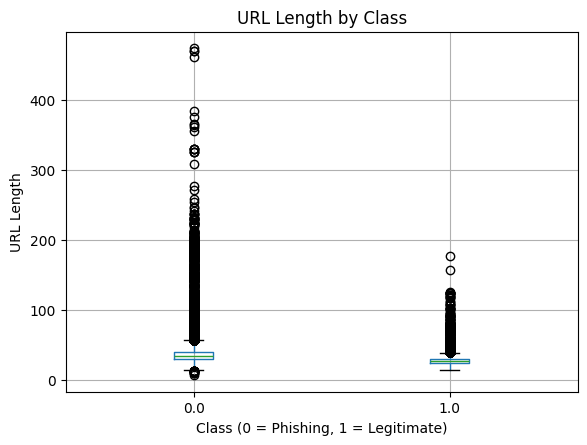

In [37]:
import matplotlib.pyplot as plt

feature_df.boxplot(
    column="URL_length",
    by="ClassLabel"
)

plt.title("URL Length by Class")
plt.suptitle("")
plt.xlabel("Class (0 = Phishing, 1 = Legitimate)")
plt.ylabel("URL Length")
plt.show()

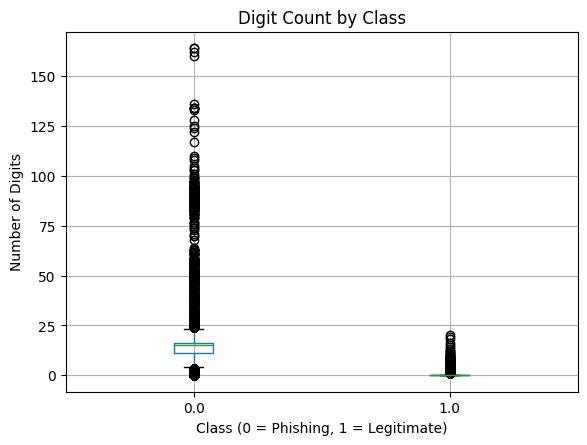

In [38]:
feature_df.boxplot(
    column="digit_count",
    by="ClassLabel"
)

plt.title("Digit Count by Class")
plt.suptitle("")
plt.xlabel("Class (0 = Phishing, 1 = Legitimate)")
plt.ylabel("Number of Digits")
plt.show()

In [50]:
dataset[
    (dataset["ClassLabel"] == 1) &
    (feature_df["digit_count"] > 0)
]["URL"].head(20)

,URL
63495,https://stackoverflow.com/questions/79030270/h...
63506,https://stackoverflow.com/questions/79030219/c...
63511,https://stackoverflow.com/questions/79030239/a...
63513,https://stackoverflow.com/questions/79030244/u...
63518,https://stackoverflow.com/questions/79030216/w...
63520,https://stackoverflow.com/questions/79030242/n...
63524,https://stackoverflow.com/questions/79030226/p...
63525,https://stackoverflow.com/questions/79030256/h...
63526,https://stackoverflow.com/questions/79030276/a...
63528,https://stackoverflow.com/questions/79030215/h...


In [51]:
dataset[
    (dataset["ClassLabel"] == 0) &
    (feature_df["digit_count"] < 3)
]["URL"].head(20)

,URL
0,https://keraekken-loagginnusa.godaddysites.com/
1,https://metamsk01lgiix.godaddysites.com/
2,http://myglobaltech.in/
3,http://djtool-for-spotify.com/
4,https://scearmcoommunnlty.com/invent/freind/get
5,http://instagramtick-git-master-behhruzs-proje...
9,http://molina-c2f.pages.dev/
10,https://officalmetamask.gitbook.io/us/
12,https://sjhjjhsjjnm.wixsite.com/my-site-1
14,http://sretyuj.weebly.com/


In [71]:
feature_df.groupby("ClassLabel")[
    ["digit_count", "hostname_digit_count"]
].mean()

,digit_count,hostname_digit_count
ClassLabel,,
0.0,13.475902,7.998803
1.0,0.072097,0.051792


In [72]:
feature_df.groupby("ClassLabel")[
    ["digit_count", "hostname_digit_count"]
].median()

,digit_count,hostname_digit_count
ClassLabel,,
0.0,15.0,10.0
1.0,0.0,0.0


In [73]:
pd.crosstab(
    feature_df["ClassLabel"],
    feature_df["hostname_digit_count"] > 0,
    normalize="index"
) * 100

hostname_digit_count,False,True
ClassLabel,,
0.0,21.758647,78.241353
1.0,97.346174,2.653826
